# QuoteGuard Parser Lab

This notebook is the current working surface for QuoteGuard.

Scope for now:

- audit the local PDF corpus
- compare parser outputs
- inspect extracted structure manually
- export parser-lab artefacts to `data/processed/parser_lab`

Out of scope for now:

- retrieval benchmarking
- LLM integration
- guardrails
- app UI


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, UTC
import hashlib
import json
from pathlib import Path
import statistics
import time

from IPython.display import HTML, display
import matplotlib.pyplot as plt
import pandas as pd

try:
    import fitz  # PyMuPDF
except ImportError:
    fitz = None

try:
    import pymupdf4llm
except ImportError:
    pymupdf4llm = None

try:
    from docling.document_converter import DocumentConverter
except ImportError:
    DocumentConverter = None

try:
    from pypdf import PdfReader
except ImportError:
    PdfReader = None


/Users/williamcatt/Documents/Projects/QuoteGuard/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = ROOT / 'data' / 'raw_pdfs'
PROCESSED_DIR = ROOT / 'data' / 'processed' / 'parser_lab'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATHS = sorted(path for path in RAW_DIR.glob('*.pdf') if path.is_file())
ROOT, RAW_DIR, PROCESSED_DIR, len(PDF_PATHS)


(PosixPath('/Users/williamcatt/Documents/Projects/QuoteGuard'),
 PosixPath('/Users/williamcatt/Documents/Projects/QuoteGuard/data/raw_pdfs'),
 PosixPath('/Users/williamcatt/Documents/Projects/QuoteGuard/data/processed/parser_lab'),
 1)

## Corpus Audit Helpers

In [3]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def page_count(path: Path) -> int | None:
    if fitz is not None:
        return fitz.open(path).page_count
    if PdfReader is not None:
        return len(PdfReader(str(path)).pages)
    return None


def sample_text_metrics(path: Path, sample_pages: int = 5) -> dict:
    if fitz is None:
        return {
            'page_count': page_count(path),
            'sample_characters': None,
            'native_pdf': None,
            'has_multi_column_layout': None,
            'has_repeated_headers_footers': None,
            'has_page_numbers': None,
            'source_version_date': None,
        }

    doc = fitz.open(path)
    pages = min(doc.page_count, sample_pages)
    page_texts = []
    multi_column_flags = []
    headers = []
    footers = []

    for index in range(pages):
        page = doc.load_page(index)
        page_texts.append(page.get_text('text'))
        blocks = [block for block in page.get_text('blocks') if len(block) >= 5 and str(block[4]).strip()]
        if blocks:
            x_positions = sorted({round(block[0], 1) for block in blocks})
            multi_column_flags.append(len(x_positions) >= 2 and max(x_positions) - min(x_positions) > 120)
            ordered = sorted(blocks, key=lambda block: (block[1], block[0]))
            headers.append(str(ordered[0][4]).strip())
            footers.append(str(ordered[-1][4]).strip())

    sample_characters = sum(len(text.strip()) for text in page_texts)
    repeated_header = len(set(value for value in headers if value)) < len([value for value in headers if value]) if headers else False
    repeated_footer = len(set(value for value in footers if value)) < len([value for value in footers if value]) if footers else False
    has_page_numbers = any(str(i + 1) in footer for i, footer in enumerate(footers)) if footers else False
    metadata = doc.metadata or {}

    return {
        'page_count': doc.page_count,
        'sample_characters': sample_characters,
        'native_pdf': sample_characters > 400,
        'has_multi_column_layout': any(multi_column_flags),
        'has_repeated_headers_footers': repeated_header or repeated_footer,
        'has_page_numbers': has_page_numbers,
        'source_version_date': metadata.get('subject') or metadata.get('title') or metadata.get('creationDate') or metadata.get('modDate'),
    }


def layout_profile(metrics: dict) -> dict:
    sample_characters = metrics.get('sample_characters') or 0
    return {
        'text_heavy': sample_characters > 3000,
        'table_heavy': 'manual_review',
        'form_heavy': 'manual_review',
        'image_heavy': sample_characters < 200 if metrics.get('sample_characters') is not None else 'manual_review',
    }


def audit_pdf(path: Path) -> dict:
    metrics = sample_text_metrics(path)
    return {
        'file_name': path.name,
        'file_size_bytes': path.stat().st_size,
        'page_count': metrics['page_count'],
        'source_version_date': metrics['source_version_date'],
        'native_pdf': metrics['native_pdf'],
        'layout_profile': layout_profile(metrics),
        'has_multi_column_layout': metrics['has_multi_column_layout'],
        'has_repeated_headers_footers': metrics['has_repeated_headers_footers'],
        'has_page_numbers': metrics['has_page_numbers'],
        'has_tables_across_page_breaks': 'manual_review',
        'expected_retrieval_difficulty': 'manual_review',
        'checksum_sha256': sha256_file(path),
    }


In [4]:
corpus_audit_rows = [audit_pdf(path) for path in PDF_PATHS]
corpus_audit_df = pd.DataFrame(corpus_audit_rows)
corpus_audit_df


,file_name,file_size_bytes,page_count,source_version_date,native_pdf,layout_profile,has_multi_column_layout,has_repeated_headers_footers,has_page_numbers,has_tables_across_page_breaks,expected_retrieval_difficulty,checksum_sha256
0,Allianz_Business_PDS.pdf,574374,100,untitled,True,"{'text_heavy': True, 'table_heavy': 'manual_re...",True,False,True,manual_review,manual_review,27c7e8996cfad3f3d97a8ab153edfb2ae75eadd26a51c3...


In [5]:
corpus_audit_df.to_csv(PROCESSED_DIR / 'corpus_audit.csv', index=False)
(PROCESSED_DIR / 'corpus_audit.json').write_text(json.dumps(corpus_audit_rows, indent=2) + '\n', encoding='utf-8')
PROCESSED_DIR / 'corpus_audit.csv'


PosixPath('/Users/williamcatt/Documents/Projects/QuoteGuard/data/processed/parser_lab/corpus_audit.csv')

## Parser Comparison Helpers

In [6]:
@dataclass
class ParsedSection:
    heading: str
    text: str
    page_number: int
    section_path: list[str]


def sectionize_markdown(markdown_text: str, page_number: int = 1) -> list[ParsedSection]:
    sections: list[ParsedSection] = []
    current_heading = 'Document'
    current_path = [current_heading]
    buffer: list[str] = []

    def flush() -> None:
        if not buffer:
            return
        text = '\n'.join(buffer).strip()
        if not text:
            return
        sections.append(ParsedSection(current_heading, text, page_number, list(current_path)))
        buffer.clear()

    for raw_line in markdown_text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if line.startswith('#'):
            flush()
            level = len(line) - len(line.lstrip('#'))
            heading = line.lstrip('#').strip() or 'Untitled'
            if level <= 1:
                current_path = [heading]
            else:
                current_path = current_path[: max(0, level - 1)] + [heading]
            current_heading = heading
            continue
        buffer.append(line)
    flush()
    return sections or [ParsedSection('Document', markdown_text.strip() or 'No text extracted', page_number, ['Document'])]


def parse_with_pymupdf4llm(path: Path) -> list[dict]:
    if pymupdf4llm is None:
        raise RuntimeError('pymupdf4llm is not installed')
    pages = pymupdf4llm.to_markdown(str(path), page_chunks=True)
    sections: list[dict] = []
    if isinstance(pages, list):
        for idx, page in enumerate(pages, start=1):
            text = page.get('text', '')
            metadata = page.get('metadata', {})
            page_number = int(metadata.get('page') or metadata.get('page_number') or idx)
            sections.extend(section.__dict__ for section in sectionize_markdown(text, page_number=page_number))
    else:
        sections.extend(section.__dict__ for section in sectionize_markdown(str(pages), page_number=1))
    return sections


def parse_with_docling(path: Path) -> list[dict]:
    if DocumentConverter is None:
        raise RuntimeError('docling is not installed')
    converter = DocumentConverter()
    result = converter.convert(path)
    doc = result.document
    page_numbers = sorted(getattr(doc, 'pages', {}).keys()) or [1]
    sections: list[dict] = []
    for page_number in page_numbers:
        markdown_text = doc.export_to_markdown(page_no=page_number)
        sections.extend(section.__dict__ for section in sectionize_markdown(markdown_text, page_number=page_number))
    return sections


def parse_with_pymupdf_text(path: Path) -> list[dict]:
    if fitz is None:
        raise RuntimeError('pymupdf is not installed')
    doc = fitz.open(path)
    sections: list[dict] = []
    for index in range(doc.page_count):
        text = doc.load_page(index).get_text('text').strip()
        if text:
            sections.append({
                'heading': f'Page {index + 1}',
                'text': text,
                'page_number': index + 1,
                'section_path': [f'Page {index + 1}'],
            })
    return sections


PARSER_FUNCTIONS = {
    'pymupdf4llm': parse_with_pymupdf4llm,
    'docling': parse_with_docling,
    'pymupdf_text': parse_with_pymupdf_text,
}


In [7]:
def run_parser(backend_name: str, pdf_paths: list[Path] | None = None) -> tuple[pd.DataFrame, Path]:
    pdf_paths = pdf_paths or PDF_PATHS
    parser_fn = PARSER_FUNCTIONS[backend_name]
    run_id = datetime.now(UTC).strftime('%Y%m%dT%H%M%SZ')
    run_dir = PROCESSED_DIR / f'{run_id}_{backend_name}'
    parsed_dir = run_dir / 'parsed'
    parsed_dir.mkdir(parents=True, exist_ok=True)
    rows = []

    for path in pdf_paths:
        started = time.perf_counter()
        try:
            sections = parser_fn(path)
            duration_ms = (time.perf_counter() - started) * 1000
            payload = {
                'source_pdf': path.name,
                'parser_backend': backend_name,
                'sections': sections,
            }
            output_path = parsed_dir / f'{path.name}.json'
            output_path.write_text(json.dumps(payload, indent=2) + '\n', encoding='utf-8')
            row = {
                'file_name': path.name,
                'parser': backend_name,
                'parse_time_ms': round(duration_ms, 2),
                'page_count': page_count(path),
                'parse_time_per_page_ms': round(duration_ms / max(1, page_count(path) or 1), 2),
                'sections_detected': len(sections),
                'total_extracted_characters': sum(len(section['text']) for section in sections),
                'tables_detected': 0,
                'failed_pages': 0,
                'empty_pages': 0,
                'warnings_errors': '',
                'output_size_bytes': output_path.stat().st_size,
                'run_dir': str(run_dir),
            }
        except Exception as exc:
            duration_ms = (time.perf_counter() - started) * 1000
            row = {
                'file_name': path.name,
                'parser': backend_name,
                'parse_time_ms': round(duration_ms, 2),
                'page_count': page_count(path),
                'parse_time_per_page_ms': None,
                'sections_detected': 0,
                'total_extracted_characters': 0,
                'tables_detected': 0,
                'failed_pages': 'unknown',
                'empty_pages': 'unknown',
                'warnings_errors': f'{type(exc).__name__}: {exc}',
                'output_size_bytes': 0,
                'run_dir': str(run_dir),
            }
        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(run_dir / 'summary.csv', index=False)
    (run_dir / 'summary.json').write_text(json.dumps(rows, indent=2) + '\n', encoding='utf-8')
    return df, run_dir


In [8]:
backend_frames = {}
backend_run_dirs = {}
for backend in ['pymupdf4llm', 'docling', 'pymupdf_text']:
    frame, run_dir = run_parser(backend)
    backend_frames[backend] = frame
    backend_run_dirs[backend] = run_dir

comparison_df = pd.concat(backend_frames.values(), ignore_index=True)
comparison_df


Loading weights: 100%|██████████| 770/770 [00:01<00:00, 635.66it/s]


,file_name,parser,parse_time_ms,page_count,parse_time_per_page_ms,sections_detected,total_extracted_characters,tables_detected,failed_pages,empty_pages,warnings_errors,output_size_bytes,run_dir
0,Allianz_Business_PDS.pdf,pymupdf4llm,12830.37,100,128.30,611,366067,0,0,0,,487337,/Users/williamcatt/Documents/Projects/QuoteGua...
1,Allianz_Business_PDS.pdf,docling,39893.48,100,398.93,619,378035,0,0,0,,499656,/Users/williamcatt/Documents/Projects/QuoteGua...
2,Allianz_Business_PDS.pdf,pymupdf_text,125.55,100,1.26,99,388564,0,0,0,,419023,/Users/williamcatt/Documents/Projects/QuoteGua...


In [9]:
comparison_summary = (
    comparison_df.groupby('parser', dropna=False)
    .agg(
        total_parse_time_ms=('parse_time_ms', 'sum'),
        avg_parse_time_ms=('parse_time_ms', 'mean'),
        avg_parse_time_per_page_ms=('parse_time_per_page_ms', 'mean'),
        total_extracted_characters=('total_extracted_characters', 'sum'),
        total_sections=('sections_detected', 'sum'),
    )
    .reset_index()
)
comparison_summary.to_csv(PROCESSED_DIR / 'parser_comparison_summary.csv', index=False)
comparison_summary


,parser,total_parse_time_ms,avg_parse_time_ms,avg_parse_time_per_page_ms,total_extracted_characters,total_sections
0,docling,39893.48,39893.48,398.93,378035,619
1,pymupdf4llm,12830.37,12830.37,128.30,366067,611
2,pymupdf_text,125.55,125.55,1.26,388564,99


## Visual Review

Use these cells to review parser results without digging through raw JSON files.

In [10]:
visual_df = comparison_df.copy()
summary_view = comparison_summary.copy()
summary_view = summary_view.sort_values('total_parse_time_ms')
display(
    summary_view.style
    .format({
        'total_parse_time_ms': '{:,.2f}',
        'avg_parse_time_ms': '{:,.2f}',
        'avg_parse_time_per_page_ms': '{:,.2f}',
        'total_extracted_characters': '{:,.0f}',
        'total_sections': '{:,.0f}',
    })
    .background_gradient(subset=['total_parse_time_ms', 'avg_parse_time_per_page_ms'], cmap='RdYlGn_r')
    .background_gradient(subset=['total_extracted_characters', 'total_sections'], cmap='YlGn')
)


,parser,total_parse_time_ms,avg_parse_time_ms,avg_parse_time_per_page_ms,total_extracted_characters,total_sections
2,pymupdf_text,125.55,125.55,1.26,"388,564",99
1,pymupdf4llm,"12,830.37","12,830.37",128.30,"366,067",611
0,docling,"39,893.48","39,893.48",398.93,"378,035",619


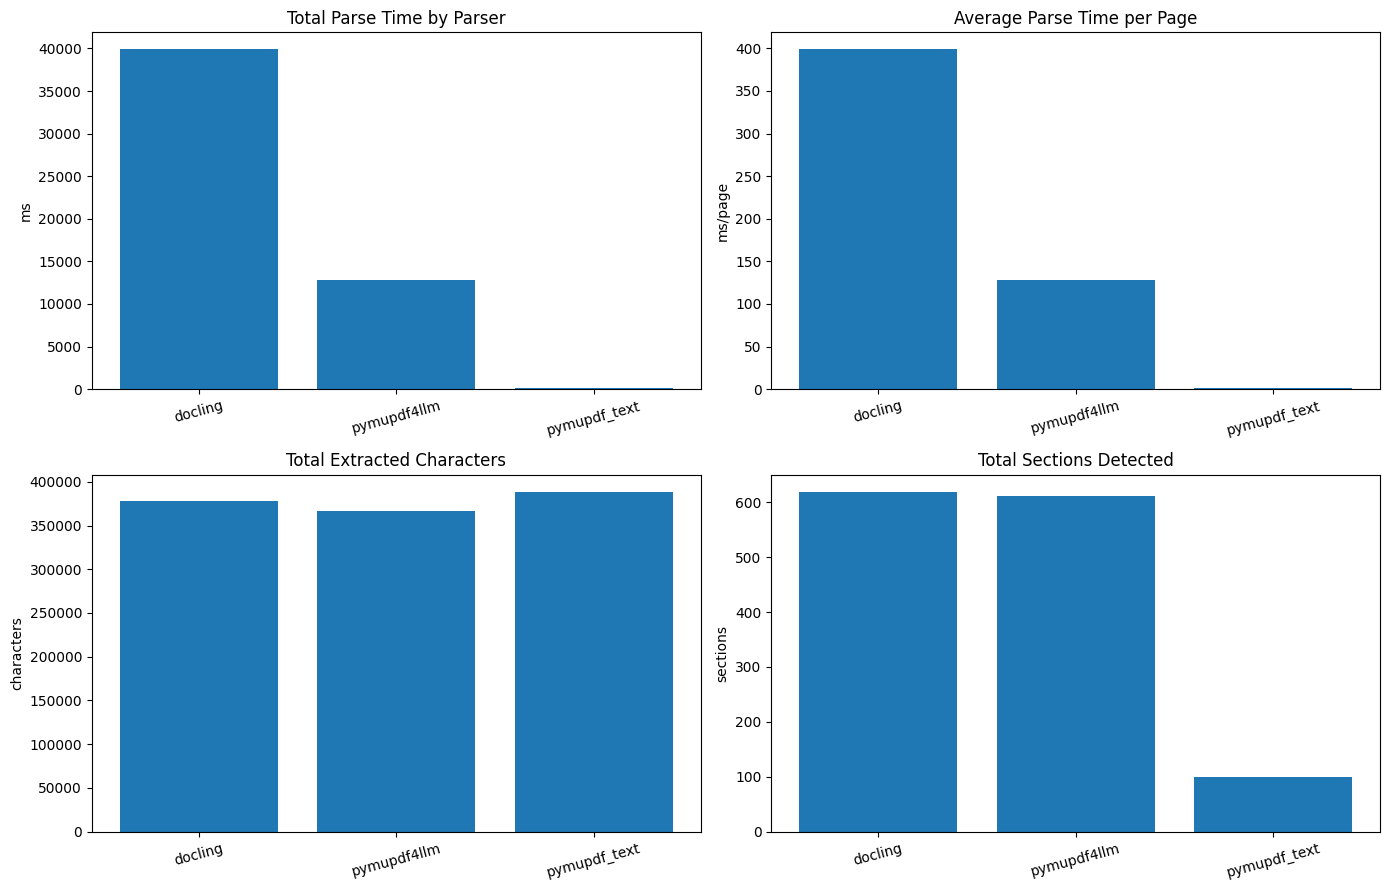

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_df = comparison_summary.sort_values('parser')

axes[0, 0].bar(plot_df['parser'], plot_df['total_parse_time_ms'])
axes[0, 0].set_title('Total Parse Time by Parser')
axes[0, 0].set_ylabel('ms')

axes[0, 1].bar(plot_df['parser'], plot_df['avg_parse_time_per_page_ms'])
axes[0, 1].set_title('Average Parse Time per Page')
axes[0, 1].set_ylabel('ms/page')

axes[1, 0].bar(plot_df['parser'], plot_df['total_extracted_characters'])
axes[1, 0].set_title('Total Extracted Characters')
axes[1, 0].set_ylabel('characters')

axes[1, 1].bar(plot_df['parser'], plot_df['total_sections'])
axes[1, 1].set_title('Total Sections Detected')
axes[1, 1].set_ylabel('sections')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=15)

fig.tight_layout()
plt.show()


In [12]:
parse_time_pivot = visual_df.pivot(index='file_name', columns='parser', values='parse_time_ms')
char_pivot = visual_df.pivot(index='file_name', columns='parser', values='total_extracted_characters')
section_pivot = visual_df.pivot(index='file_name', columns='parser', values='sections_detected')

print('Parse time by PDF and parser')
display(parse_time_pivot.style.format('{:,.2f}').background_gradient(cmap='Blues'))

print('Extracted characters by PDF and parser')
display(char_pivot.style.format('{:,.0f}').background_gradient(cmap='YlGn'))

print('Sections detected by PDF and parser')
display(section_pivot.style.format('{:,.0f}').background_gradient(cmap='PuBuGn'))


Parse time by PDF and parser


parser,docling,pymupdf4llm,pymupdf_text
file_name,,,
Allianz_Business_PDS.pdf,"39,893.48","12,830.37",125.55


Extracted characters by PDF and parser


parser,docling,pymupdf4llm,pymupdf_text
file_name,,,
Allianz_Business_PDS.pdf,"378,035","366,067","388,564"


Sections detected by PDF and parser


parser,docling,pymupdf4llm,pymupdf_text
file_name,,,
Allianz_Business_PDS.pdf,619,611,99


In [13]:
problem_rows = visual_df[visual_df['warnings_errors'].fillna('') != '']
problem_rows if not problem_rows.empty else 'No parser failures recorded in the current run set.'


'No parser failures recorded in the current run set.'

## Manual Inspection Helpers

In [14]:
def load_sections(run_dir: Path, pdf_name: str) -> list[dict]:
    path = run_dir / 'parsed' / f'{pdf_name}.json'
    payload = json.loads(path.read_text(encoding='utf-8'))
    return payload['sections']


def preview_sections(run_dir: Path, pdf_name: str, limit: int = 8, pages: list[int] | None = None) -> pd.DataFrame:
    sections = load_sections(run_dir, pdf_name)
    if pages is not None:
        page_set = set(pages)
        sections = [section for section in sections if int(section['page_number']) in page_set]
    sections = sections[:limit]
    rows = []
    for section in sections:
        rows.append({
            'heading': section['heading'],
            'page_number': section['page_number'],
            'section_path': ' > '.join(section['section_path']),
            'preview': ' '.join(section['text'].split())[:220],
        })
    return pd.DataFrame(rows)


def side_by_side_parser_preview(
    pdf_name: str,
    parsers: list[str] | None = None,
    pages: list[int] | None = None,
    limit: int = 8,
) -> None:
    parsers = parsers or list(backend_run_dirs)
    blocks = []
    for parser_name in parsers:
        run_dir = backend_run_dirs[parser_name]
        df = preview_sections(run_dir, pdf_name, limit=limit, pages=pages)
        if df.empty:
            html_table = '<p><em>No sections found for this selection.</em></p>'
        else:
            html_table = df.to_html(index=False, escape=False)
        blocks.append(
            f"<div style='flex:1; min-width:320px;'>"
            f"<h4>{parser_name} :: {pdf_name}</h4>{html_table}</div>"
        )
    display(HTML("<div style='display:flex; gap:24px; align-items:flex-start; flex-wrap:wrap;'>" + ''.join(blocks) + '</div>'))


In [15]:
PDF_PATHS[0].name if PDF_PATHS else None

'Allianz_Business_PDS.pdf'

In [16]:
sample_pdf = PDF_PATHS[0].name if PDF_PATHS else None
if sample_pdf:
    for backend, run_dir in backend_run_dirs.items():
        print(f'\n=== {backend} :: {sample_pdf} ===')
        display(preview_sections(run_dir, sample_pdf, limit=6))



=== pymupdf4llm :: Allianz_Business_PDS.pdf ===


,heading,page_number,section_path,preview
0,Document,1,Document,**==> picture [39 x 39] intentionally omitted ...
1,Business Insurance Pack,1,Document > Business Insurance Pack,Product Disclosure Statement (PDS) **==> pictu...
2,About Allianz,2,Document > About Allianz,The insurer of this product is Allianz Austral...
3,General Information,2,Document > General Information,The General Information set out below is provi...
4,Claims made,2,Document > Claims made,The Management Liability Section of the policy...
5,Document,3,Document,This page has been left blank intentionally. 1



=== docling :: Allianz_Business_PDS.pdf ===


,heading,page_number,section_path,preview
0,Document,1,Document,<!-- image -->
1,Business Insurance Pack,1,Document > Business Insurance Pack,Product Disclosure Statement (PDS) <!-- image -->
2,About Allianz,2,Document > About Allianz,The insurer of this product is Allianz Austral...
3,General Information,2,Document > General Information,The General Information set out below is provi...
4,Claims made,2,Document > Claims made,The Management Liability Section of the policy...
5,Document,3,Document,This page has been left blank intentionally.



=== pymupdf_text :: Allianz_Business_PDS.pdf ===


,heading,page_number,section_path,preview
0,Page 1,1,Page 1,Product Disclosure Statement (PDS) Business In...
1,Page 2,2,Page 2,Preparation Date: 11/04/2024. About Allianz Th...
2,Page 3,3,Page 3,1 This page has been left blank intentionally.
3,Page 4,4,Page 4,2 Table of contents page Introduction 5 Summar...
4,Page 5,5,Page 5,3 page Public and Products Liability Section 4...
5,Page 6,6,Page 6,4 page Part B – Employment Practices Liability...


## Side-by-Side Parser Review

Choose a PDF and page range, then compare parser previews directly next to each other.

In [17]:
comparison_pdf = next((path.name for path in PDF_PATHS if path.name == 'Allianz_Business_PDS.pdf'), PDF_PATHS[0].name if PDF_PATHS else None)
comparison_pages = [1, 2, 3]
comparison_limit = 6
comparison_parsers = ['pymupdf4llm', 'docling', 'pymupdf_text']
comparison_pdf, comparison_pages, comparison_limit, comparison_parsers


('Allianz_Business_PDS.pdf',
 [1, 2, 3],
 6,
 ['pymupdf4llm', 'docling', 'pymupdf_text'])

In [18]:
if comparison_pdf:
    side_by_side_parser_preview(
        comparison_pdf,
        parsers=comparison_parsers,
        pages=comparison_pages,
        limit=comparison_limit,
    )


heading,page_number,section_path,preview
Document,1,Document,**==> picture [39 x 39] intentionally omitted <==**
Business Insurance Pack,1,Document > Business Insurance Pack,Product Disclosure Statement (PDS) **==> picture [511 x 555] intentionally omitted <==**
About Allianz,2,Document > About Allianz,"The insurer of this product is Allianz Australia Insurance Limited ABN 15 000 122 850 (Allianz) AFS Licence No. 234708, an authorised Australian insurer, regulated by the Australian Prudential Regulation Authority (APRA)"
General Information,2,Document > General Information,"The General Information set out below is provided for your information only. It does not form part of the insurance contract with you, and is not part of the policy. Nothing contained in the General Information imposes c"
Claims made,2,Document > Claims made,The Management Liability Section of the policy operates on a “claims made and notified” basis. This means that the section covers you for claims as defined in the Management Liability Section made against you and notifie
Document,3,Document,This page has been left blank intentionally. 1
heading,page_number,section_path,preview
Document,1,Document,<!-- image -->
Business Insurance Pack,1,Document > Business Insurance Pack,Product Disclosure Statement (PDS) <!-- image -->
About Allianz,2,Document > About Allianz,"The insurer of this product is Allianz Australia Insurance Limited ABN 15 000 122 850 (Allianz) AFS Licence No. 234708, an authorised Australian insurer, regulated by the Australian Prudential Regulation Authority (APRA)"


## Provisional Assessment

These notes are intentionally provisional and based only on the current sample inspection.
Do not lock the parser until you repeat this on the actual target corpus.

In [19]:
provisional_assessment = pd.DataFrame([
    {
        'parser': 'docling',
        'provisional_position': 'selected for Phase 2',
        'what_current_metrics_say': 'Slower than pymupdf4llm on the current sample, but runtime is acceptable for the one-PDF scope of this notebook.',
        'what_current_preview_says': 'This is the parser being taken forward because the current manual preference is for docling output quality over raw speed.',
        'what_to_check_next': 'Re-run the parser cells with page-aware export, then confirm definitions, exclusions, and table-heavy pages still look clean before locking chunking.',
    },
    {
        'parser': 'pymupdf4llm',
        'provisional_position': 'strong fallback option',
        'what_current_metrics_say': 'Much faster than docling on the current sample, with extracted characters and section counts in the same range.',
        'what_current_preview_says': 'Still the main local alternative if docling later proves weak on page fidelity or chunk quality.',
        'what_to_check_next': 'Keep its run outputs for comparison while evaluating docling chunking and retrieval.',
    },
    {
        'parser': 'pymupdf_text',
        'provisional_position': 'baseline only',
        'what_current_metrics_say': 'By far the fastest parser and high raw text extraction, but with far fewer sections detected.',
        'what_current_preview_says': 'Mostly page-level blobs with weak semantic headings, which is poor for later section-aware retrieval.',
        'what_to_check_next': 'Keep only as a speed baseline or fallback, not as the default parser candidate.',
    },
])
display(provisional_assessment.style.set_properties(**{'white-space': 'normal'}))


,parser,provisional_position,what_current_metrics_say,what_current_preview_says,what_to_check_next
0,docling,selected for Phase 2,"Slower than pymupdf4llm on the current sample, but runtime is acceptable for the one-PDF scope of this notebook.",This is the parser being taken forward because the current manual preference is for docling output quality over raw speed.,"Re-run the parser cells with page-aware export, then confirm definitions, exclusions, and table-heavy pages still look clean before locking chunking."
1,pymupdf4llm,strong fallback option,"Much faster than docling on the current sample, with extracted characters and section counts in the same range.",Still the main local alternative if docling later proves weak on page fidelity or chunk quality.,Keep its run outputs for comparison while evaluating docling chunking and retrieval.
2,pymupdf_text,baseline only,"By far the fastest parser and high raw text extraction, but with far fewer sections detected.","Mostly page-level blobs with weak semantic headings, which is poor for later section-aware retrieval.","Keep only as a speed baseline or fallback, not as the default parser candidate."


## Manual Scoring Template

Fill this after inspecting parser outputs.

Suggested criteria:

- reading_order
- heading_preservation
- paragraph_breaks
- bullet_lists
- table_quality
- cross_page_continuity
- header_footer_noise
- page_metadata_preservation


In [20]:
manual_scoring = pd.DataFrame([
    {
        'pdf_name': path.name,
        'parser': backend,
        'reading_order': None,
        'heading_preservation': None,
        'paragraph_breaks': None,
        'bullet_lists': None,
        'table_quality': None,
        'cross_page_continuity': None,
        'header_footer_noise': None,
        'page_metadata_preservation': None,
        'notes': '',
    }
    for path in PDF_PATHS
    for backend in backend_run_dirs
])
manual_scoring


,pdf_name,parser,reading_order,heading_preservation,paragraph_breaks,bullet_lists,table_quality,cross_page_continuity,header_footer_noise,page_metadata_preservation,notes
0,Allianz_Business_PDS.pdf,pymupdf4llm,None,None,None,None,None,None,None,None,
1,Allianz_Business_PDS.pdf,docling,None,None,None,None,None,None,None,None,
2,Allianz_Business_PDS.pdf,pymupdf_text,None,None,None,None,None,None,None,None,


## Phase 2: Chunking and Retrieval

With `docling` selected for this one-PDF workflow, the rest of the work should stay in this notebook for now.

The goal of this phase is to:
- lock one parser run as the canonical parsed source
- compare a few chunking strategies and token caps
- inspect chunk quality directly in tables and charts
- benchmark lightweight retrieval before adding embeddings, an LLM, or guardrails


## Selected Parser Context

This cell pins the parser and PDF that the chunking and retrieval lab will use.

If you change the selected parser, re-run the parser comparison section above first so `backend_run_dirs` points at fresh outputs.


In [21]:
selected_parser = 'docling'
selected_pdf = next((path.name for path in PDF_PATHS if path.name == 'Allianz_Business_PDS.pdf'), PDF_PATHS[0].name if PDF_PATHS else None)
selected_run_dir = backend_run_dirs[selected_parser]
selected_sections = load_sections(selected_run_dir, selected_pdf) if selected_pdf else []
selected_pdf_stem = Path(selected_pdf).stem if selected_pdf else 'no_pdf'

selected_parser_summary = comparison_df[
    (comparison_df['parser'] == selected_parser) & (comparison_df['file_name'] == selected_pdf)
].copy()
selected_parser_summary


,file_name,parser,parse_time_ms,page_count,parse_time_per_page_ms,sections_detected,total_extracted_characters,tables_detected,failed_pages,empty_pages,warnings_errors,output_size_bytes,run_dir
1,Allianz_Business_PDS.pdf,docling,39893.48,100,398.93,619,378035,0,0,0,,499656,/Users/williamcatt/Documents/Projects/QuoteGua...


## Chunking Helpers

These helpers stay dependency-light on purpose. They use the parsed section output from the chosen parser and compare a few chunking methods directly:
- `section_aware`: each section stays self-contained unless it must be split
- `hybrid_section_aware`: adjacent sections are merged up to the token cap
- `page_based`: page-grouped baseline


In [22]:
import math
import re
from collections import Counter

TOKEN_PATTERN = re.compile(r"[A-Za-z0-9']+")
STOPWORDS = {
    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'by', 'for', 'from', 'if', 'in', 'is', 'it', 'of', 'on', 'or', 'that',
    'the', 'this', 'to', 'we', 'with', 'you', 'your'
}
NOISE_REASONS = {
    'empty_body',
    'image_only',
    'blank_page',
    'table_of_contents',
    'too_short_generic',
}


def normalize_space(text: str) -> str:
    return ' '.join((text or '').split())


def strip_placeholder_markup(text: str) -> str:
    text = text or ''
    text = text.replace('<!-- image -->', ' ')
    text = text.replace('**==>', ' ')
    text = text.replace('intentionally omitted', ' ')
    return normalize_space(text)


def simple_tokenize(text: str) -> list[str]:
    return TOKEN_PATTERN.findall((text or '').lower())


def section_heading_path(section: dict) -> str:
    path = section.get('section_path') or [section.get('heading', 'Document')]
    return ' > '.join(path)


def cleaned_section_body(section: dict) -> str:
    return strip_placeholder_markup(section.get('text', ''))


def classify_section_noise(section: dict) -> str | None:
    body = cleaned_section_body(section)
    heading_path = section_heading_path(section).lower()
    tokens = simple_tokenize(body)

    if not body:
        return 'empty_body'
    if 'this page has been left blank intentionally' in body.lower():
        return 'blank_page'
    if 'table of contents' in heading_path:
        return 'table_of_contents'
    if not tokens:
        return 'empty_body'
    if set(tokens).issubset({'document', 'image'}):
        return 'image_only'
    if len(tokens) < 8 and heading_path.strip().lower() == 'document':
        return 'too_short_generic'
    if body.lower() in {'no text extracted', 'document no text extracted'}:
        return 'empty_body'
    return None


def prepare_sections_for_chunking(sections: list[dict]) -> tuple[list[dict], pd.DataFrame, pd.DataFrame]:
    kept_sections = []
    report_rows = []
    filtered_preview_rows = []
    for section in sections:
        reason = classify_section_noise(section)
        body = cleaned_section_body(section)
        tokens = simple_tokenize(body)
        report_rows.append({
            'page_number': section.get('page_number'),
            'heading_path': section_heading_path(section),
            'token_count': len(tokens),
            'status': 'filtered' if reason else 'kept',
            'filter_reason': reason or '',
        })
        if reason:
            filtered_preview_rows.append({
                'page_number': section.get('page_number'),
                'heading_path': section_heading_path(section),
                'filter_reason': reason,
                'preview': body[:220],
            })
            continue
        kept_section = dict(section)
        kept_section['text'] = body
        kept_sections.append(kept_section)

    report_df = pd.DataFrame(report_rows)
    summary_df = pd.DataFrame([
        {
            'raw_sections': len(sections),
            'kept_sections': sum(report_df['status'] == 'kept') if not report_df.empty else 0,
            'filtered_sections': sum(report_df['status'] == 'filtered') if not report_df.empty else 0,
            'filtered_blank_page': int((report_df['filter_reason'] == 'blank_page').sum()) if not report_df.empty else 0,
            'filtered_image_only': int((report_df['filter_reason'] == 'image_only').sum()) if not report_df.empty else 0,
            'filtered_toc': int((report_df['filter_reason'] == 'table_of_contents').sum()) if not report_df.empty else 0,
            'filtered_too_short_generic': int((report_df['filter_reason'] == 'too_short_generic').sum()) if not report_df.empty else 0,
            'filtered_empty_body': int((report_df['filter_reason'] == 'empty_body').sum()) if not report_df.empty else 0,
        }
    ])
    filtered_preview_df = pd.DataFrame(filtered_preview_rows)
    return kept_sections, summary_df, filtered_preview_df


def section_payload_text(section: dict, prepend_heading_path: bool = True) -> str:
    body = cleaned_section_body(section)
    if not body:
        return ''
    heading_path = section_heading_path(section)
    if prepend_heading_path and heading_path:
        return f"{heading_path}\n{body}".strip()
    return body


def split_token_windows(tokens: list[str], max_tokens: int, overlap_tokens: int) -> list[list[str]]:
    if not tokens:
        return []
    if len(tokens) <= max_tokens:
        return [tokens]
    windows: list[list[str]] = []
    step = max(1, max_tokens - overlap_tokens)
    start = 0
    while start < len(tokens):
        window = tokens[start:start + max_tokens]
        if not window:
            break
        windows.append(window)
        if start + max_tokens >= len(tokens):
            break
        start += step
    return windows


def make_chunk(
    *,
    chunk_id: str,
    parser_name: str,
    pdf_name: str,
    chunking_method: str,
    chunk_size: int,
    overlap_ratio: float,
    texts: list[str],
    page_numbers: list[int],
    heading_paths: list[str],
) -> dict:
    merged_text = '\n\n'.join(text for text in texts if text).strip()
    token_count = len(simple_tokenize(merged_text))
    return {
        'chunk_id': chunk_id,
        'parser': parser_name,
        'pdf_name': pdf_name,
        'chunking_method': chunking_method,
        'chunk_size': chunk_size,
        'overlap_ratio': overlap_ratio,
        'heading_path': ' || '.join(path for path in heading_paths if path),
        'page_numbers': sorted({int(page) for page in page_numbers if page is not None}),
        'text': merged_text,
        'token_count': token_count,
        'source_section_count': len(texts),
    }


def build_section_aware_chunks(
    sections: list[dict],
    *,
    parser_name: str,
    pdf_name: str,
    chunk_size: int,
    overlap_ratio: float,
    prepend_heading_path: bool = True,
) -> list[dict]:
    chunks: list[dict] = []
    overlap_tokens = int(chunk_size * overlap_ratio)
    chunk_index = 1
    for section in sections:
        payload_text = section_payload_text(section, prepend_heading_path=prepend_heading_path)
        if not payload_text:
            continue
        tokens = simple_tokenize(payload_text)
        windows = split_token_windows(tokens, chunk_size, overlap_tokens)
        for window_index, window_tokens in enumerate(windows, start=1):
            chunks.append(make_chunk(
                chunk_id=f'{chunk_index:04d}.{window_index}',
                parser_name=parser_name,
                pdf_name=pdf_name,
                chunking_method='section_aware',
                chunk_size=chunk_size,
                overlap_ratio=overlap_ratio,
                texts=[' '.join(window_tokens)],
                page_numbers=[section.get('page_number')],
                heading_paths=[section_heading_path(section)],
            ))
        chunk_index += 1
    return chunks


def build_page_based_chunks(
    sections: list[dict],
    *,
    parser_name: str,
    pdf_name: str,
    chunk_size: int,
    overlap_ratio: float,
    prepend_heading_path: bool = True,
) -> list[dict]:
    grouped: dict[int, list[dict]] = {}
    for section in sections:
        grouped.setdefault(int(section.get('page_number', 1)), []).append(section)

    chunks: list[dict] = []
    overlap_tokens = int(chunk_size * overlap_ratio)
    for page_number in sorted(grouped):
        texts = [section_payload_text(section, prepend_heading_path=prepend_heading_path) for section in grouped[page_number]]
        merged_text = '\n\n'.join(text for text in texts if text).strip()
        if not merged_text:
            continue
        windows = split_token_windows(simple_tokenize(merged_text), chunk_size, overlap_tokens)
        for window_index, window_tokens in enumerate(windows, start=1):
            chunks.append(make_chunk(
                chunk_id=f'p{page_number:03d}.{window_index}',
                parser_name=parser_name,
                pdf_name=pdf_name,
                chunking_method='page_based',
                chunk_size=chunk_size,
                overlap_ratio=overlap_ratio,
                texts=[' '.join(window_tokens)],
                page_numbers=[page_number],
                heading_paths=[section_heading_path(section) for section in grouped[page_number]],
            ))
    return chunks


def build_hybrid_section_aware_chunks(
    sections: list[dict],
    *,
    parser_name: str,
    pdf_name: str,
    chunk_size: int,
    overlap_ratio: float,
    prepend_heading_path: bool = True,
) -> list[dict]:
    prepared = []
    for section in sections:
        text = section_payload_text(section, prepend_heading_path=prepend_heading_path)
        tokens = simple_tokenize(text)
        if not tokens:
            continue
        prepared.append({
            'section': section,
            'text': text,
            'tokens': tokens,
            'heading_path': section_heading_path(section),
            'page_number': int(section.get('page_number', 1)),
        })

    chunks: list[dict] = []
    overlap_tokens = int(chunk_size * overlap_ratio)
    start = 0
    chunk_index = 1
    while start < len(prepared):
        current = []
        token_budget = 0
        end = start
        while end < len(prepared):
            candidate = prepared[end]
            token_len = len(candidate['tokens'])
            if current and token_budget + token_len > chunk_size:
                break
            if not current and token_len > chunk_size:
                windows = split_token_windows(candidate['tokens'], chunk_size, overlap_tokens)
                for window_index, window_tokens in enumerate(windows, start=1):
                    chunks.append(make_chunk(
                        chunk_id=f'h{chunk_index:04d}.{window_index}',
                        parser_name=parser_name,
                        pdf_name=pdf_name,
                        chunking_method='hybrid_section_aware',
                        chunk_size=chunk_size,
                        overlap_ratio=overlap_ratio,
                        texts=[' '.join(window_tokens)],
                        page_numbers=[candidate['page_number']],
                        heading_paths=[candidate['heading_path']],
                    ))
                chunk_index += 1
                end += 1
                break
            current.append(candidate)
            token_budget += token_len
            end += 1

        if current:
            chunks.append(make_chunk(
                chunk_id=f'h{chunk_index:04d}',
                parser_name=parser_name,
                pdf_name=pdf_name,
                chunking_method='hybrid_section_aware',
                chunk_size=chunk_size,
                overlap_ratio=overlap_ratio,
                texts=[entry['text'] for entry in current],
                page_numbers=[entry['page_number'] for entry in current],
                heading_paths=[entry['heading_path'] for entry in current],
            ))
            chunk_index += 1

        if end <= start:
            start += 1
            continue

        if overlap_tokens <= 0 or not current:
            start = end
            continue

        backfill_tokens = 0
        next_start = end
        while next_start > start and backfill_tokens < overlap_tokens:
            next_start -= 1
            backfill_tokens += len(prepared[next_start]['tokens'])
        start = next_start if next_start > start else max(start + 1, end - 1)

    return chunks


def chunk_sections(
    sections: list[dict],
    *,
    parser_name: str,
    pdf_name: str,
    method: str,
    chunk_size: int,
    overlap_ratio: float,
    prepend_heading_path: bool = True,
) -> list[dict]:
    if method == 'section_aware':
        return build_section_aware_chunks(
            sections,
            parser_name=parser_name,
            pdf_name=pdf_name,
            chunk_size=chunk_size,
            overlap_ratio=overlap_ratio,
            prepend_heading_path=prepend_heading_path,
        )
    if method == 'hybrid_section_aware':
        return build_hybrid_section_aware_chunks(
            sections,
            parser_name=parser_name,
            pdf_name=pdf_name,
            chunk_size=chunk_size,
            overlap_ratio=overlap_ratio,
            prepend_heading_path=prepend_heading_path,
        )
    if method == 'page_based':
        return build_page_based_chunks(
            sections,
            parser_name=parser_name,
            pdf_name=pdf_name,
            chunk_size=chunk_size,
            overlap_ratio=overlap_ratio,
            prepend_heading_path=prepend_heading_path,
        )
    raise ValueError(f'Unsupported chunking method: {method}')


def chunk_stats(chunks: list[dict], chunk_size: int) -> dict:
    token_counts = [chunk['token_count'] for chunk in chunks]
    if not token_counts:
        return {
            'chunk_count': 0,
            'avg_tokens': 0,
            'median_tokens': 0,
            'min_tokens': 0,
            'max_tokens': 0,
            'tiny_chunks_under_50': 0,
            'oversized_chunks': 0,
            'duplicate_chunk_rate': 0.0,
            'headings_retained': False,
            'page_metadata_retained': False,
            'unique_pages_covered': 0,
            'avg_source_sections_per_chunk': 0,
        }
    normalized_texts = [normalize_space(chunk['text']).lower() for chunk in chunks]
    duplicate_count = len(normalized_texts) - len(set(normalized_texts))
    return {
        'chunk_count': len(chunks),
        'avg_tokens': round(sum(token_counts) / len(token_counts), 2),
        'median_tokens': round(statistics.median(token_counts), 2),
        'min_tokens': min(token_counts),
        'max_tokens': max(token_counts),
        'tiny_chunks_under_50': sum(1 for count in token_counts if count < 50),
        'oversized_chunks': sum(1 for count in token_counts if count > chunk_size),
        'duplicate_chunk_rate': round(duplicate_count / len(chunks), 3),
        'headings_retained': all(bool(chunk['heading_path']) for chunk in chunks),
        'page_metadata_retained': all(bool(chunk['page_numbers']) for chunk in chunks),
        'unique_pages_covered': len({page for chunk in chunks for page in chunk['page_numbers']}),
        'avg_source_sections_per_chunk': round(sum(chunk['source_section_count'] for chunk in chunks) / len(chunks), 2),
    }


def preview_chunks(chunks: list[dict], limit: int = 10, mode: str = 'first') -> pd.DataFrame:
    rows = []
    ordered_chunks = list(chunks)
    if mode == 'shortest':
        ordered_chunks = sorted(chunks, key=lambda chunk: chunk['token_count'])
    elif mode == 'longest':
        ordered_chunks = sorted(chunks, key=lambda chunk: chunk['token_count'], reverse=True)
    for chunk in ordered_chunks[:limit]:
        rows.append({
            'chunk_id': chunk['chunk_id'],
            'pages': ', '.join(str(page) for page in chunk['page_numbers']),
            'token_count': chunk['token_count'],
            'source_section_count': chunk['source_section_count'],
            'heading_path': chunk['heading_path'][:120],
            'preview': normalize_space(chunk['text'])[:240],
        })
    return pd.DataFrame(rows)


## Chunking Experiment Matrix

These are small, deliberate experiments for the one-PDF scope. If one setup is clearly better, stop there rather than expanding the matrix too early.


In [23]:
phase2_dir = PROCESSED_DIR / 'phase2' / f'{selected_parser}_{selected_pdf_stem}'
phase2_dir.mkdir(parents=True, exist_ok=True)

selected_sections_for_chunking, section_filter_report_df, filtered_sections_preview_df = prepare_sections_for_chunking(selected_sections)
section_filter_report_df.to_csv(phase2_dir / 'section_filter_report.csv', index=False)
filtered_sections_preview_df.to_csv(phase2_dir / 'filtered_sections_preview.csv', index=False)

display(section_filter_report_df)
if not filtered_sections_preview_df.empty:
    print('Filtered section preview')
    display(filtered_sections_preview_df.head(12))

chunking_configs = [
    {'label': 'section_500_o10', 'method': 'section_aware', 'chunk_size': 500, 'overlap_ratio': 0.10},
    {'label': 'section_800_o10', 'method': 'section_aware', 'chunk_size': 800, 'overlap_ratio': 0.10},
    {'label': 'hybrid_500_o10', 'method': 'hybrid_section_aware', 'chunk_size': 500, 'overlap_ratio': 0.10},
    {'label': 'hybrid_800_o20', 'method': 'hybrid_section_aware', 'chunk_size': 800, 'overlap_ratio': 0.20},
    {'label': 'page_800_o00', 'method': 'page_based', 'chunk_size': 800, 'overlap_ratio': 0.00},
]

all_chunks_by_config: dict[str, list[dict]] = {}
chunking_rows = []

for config in chunking_configs:
    chunks = chunk_sections(
        selected_sections_for_chunking,
        parser_name=selected_parser,
        pdf_name=selected_pdf,
        method=config['method'],
        chunk_size=config['chunk_size'],
        overlap_ratio=config['overlap_ratio'],
        prepend_heading_path=True,
    )
    all_chunks_by_config[config['label']] = chunks
    output_path = phase2_dir / f"{config['label']}_chunks.json"
    output_path.write_text(json.dumps(chunks, indent=2) + '\n', encoding='utf-8')
    stats = chunk_stats(chunks, chunk_size=config['chunk_size'])
    chunking_rows.append({
        **config,
        'raw_sections': int(section_filter_report_df['raw_sections'].iloc[0]),
        'kept_sections': int(section_filter_report_df['kept_sections'].iloc[0]),
        'filtered_sections': int(section_filter_report_df['filtered_sections'].iloc[0]),
        **stats,
        'output_path': str(output_path),
    })

chunking_summary_df = pd.DataFrame(chunking_rows).sort_values(['method', 'chunk_size', 'overlap_ratio']).reset_index(drop=True)
chunking_summary_df.to_csv(phase2_dir / 'chunking_summary.csv', index=False)
chunking_summary_df


,label,method,chunk_size,overlap_ratio,chunk_count,avg_tokens,median_tokens,min_tokens,max_tokens,tiny_chunks_under_50,oversized_chunks,duplicate_chunk_rate,headings_retained,page_metadata_retained,unique_pages_covered,output_path
0,hybrid_500_o10,hybrid_section_aware,500,0.1,227,398.39,433.0,24,500,2,0,0.000,True,True,100,/Users/williamcatt/Documents/Projects/QuoteGua...
1,hybrid_800_o20,hybrid_section_aware,800,0.2,139,682.62,727.0,24,800,1,0,0.000,True,True,100,/Users/williamcatt/Documents/Projects/QuoteGua...
2,page_800_o00,page_based,800,0.0,111,583.40,687.0,4,800,12,0,0.009,True,True,100,/Users/williamcatt/Documents/Projects/QuoteGua...
3,section_500_o10,section_aware,500,0.1,628,103.83,75.0,2,500,190,0,0.011,True,True,100,/Users/williamcatt/Documents/Projects/QuoteGua...
4,section_800_o10,section_aware,800,0.1,619,104.62,73.0,2,771,190,0,0.011,True,True,100,/Users/williamcatt/Documents/Projects/QuoteGua...


## Chunking Visual Review

Use this section to decide whether the chosen chunking setup is coherent before you benchmark retrieval.


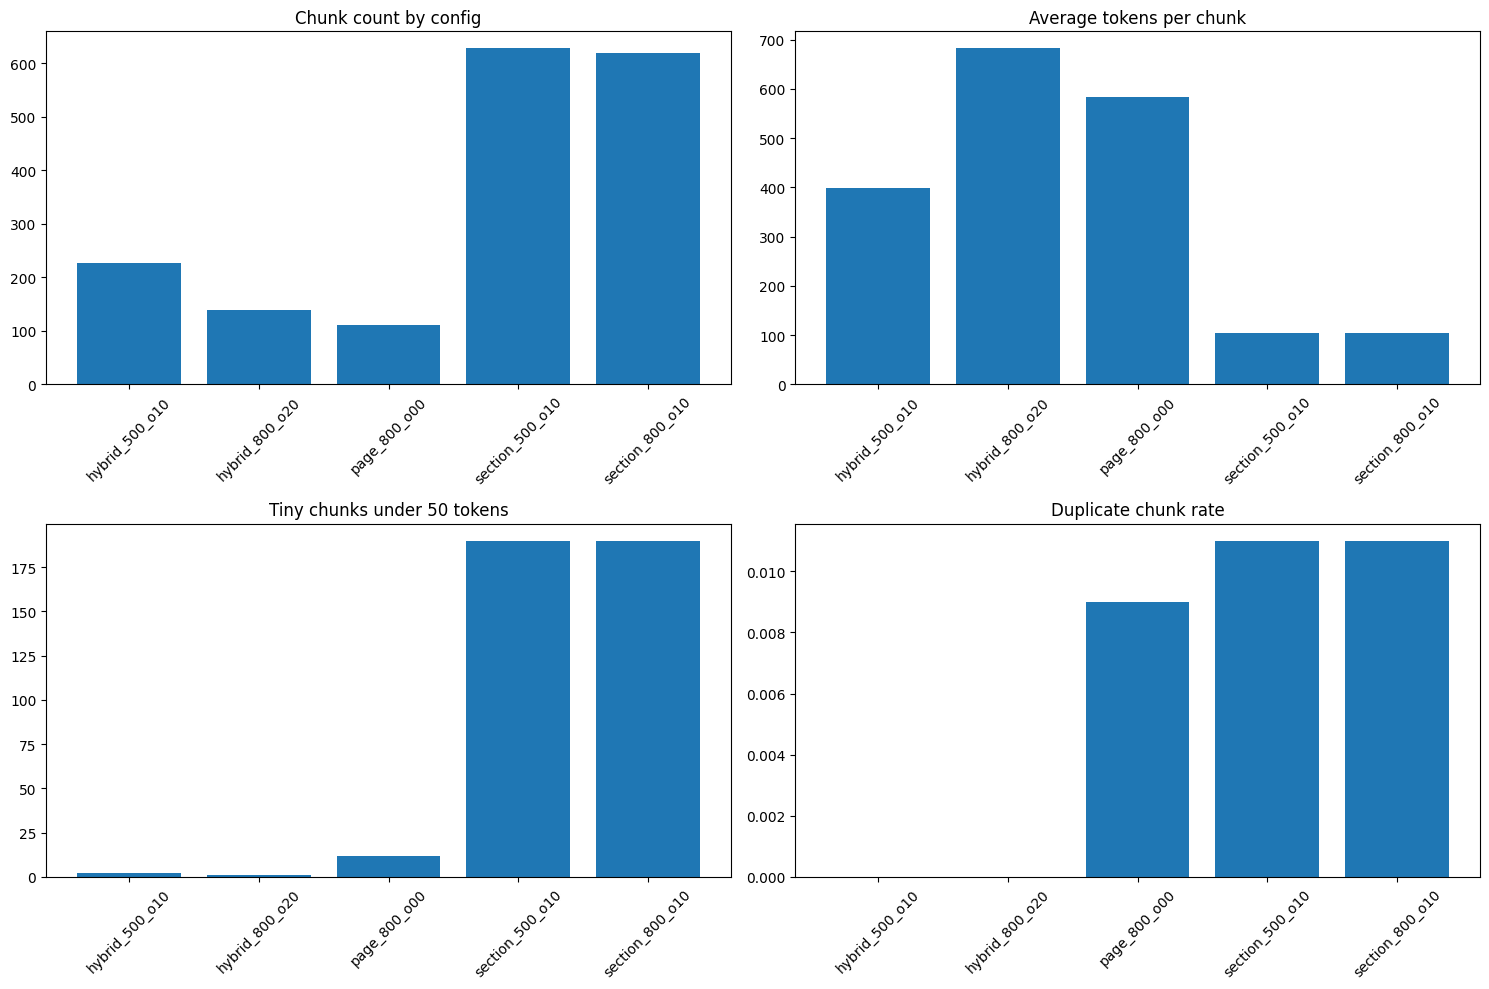

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
chunk_labels = chunking_summary_df['label']

axes[0, 0].bar(chunk_labels, chunking_summary_df['chunk_count'])
axes[0, 0].set_title('Chunk count by config')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(chunk_labels, chunking_summary_df['avg_tokens'])
axes[0, 1].set_title('Average tokens per chunk')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].bar(chunk_labels, chunking_summary_df['tiny_chunks_under_50'])
axes[1, 0].set_title('Tiny chunks under 50 tokens')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(chunk_labels, chunking_summary_df['duplicate_chunk_rate'])
axes[1, 1].set_title('Duplicate chunk rate')
axes[1, 1].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()


In [25]:
selected_chunk_label = 'hybrid_500_o10' if 'hybrid_500_o10' in all_chunks_by_config else next(iter(all_chunks_by_config))
selected_chunks = all_chunks_by_config[selected_chunk_label]

print(f'Selected chunk config for manual inspection: {selected_chunk_label}')
display(preview_chunks(selected_chunks, limit=10, mode='first'))
print('Shortest chunks')
display(preview_chunks(selected_chunks, limit=10, mode='shortest'))
print('Longest chunks')
display(preview_chunks(selected_chunks, limit=10, mode='longest'))


Selected chunk config for manual inspection: hybrid_500_o10


,chunk_id,pages,token_count,heading_path,preview
0,h0001,"1, 2",181,Document || Document > Business Insurance Pack...,Document <!-- image --> Document > Business In...
1,h0002,"2, 3",433,Document > General Information || Document > C...,Document > General Information The General Inf...
2,h0003,"2, 3",376,Document > Claims made || Document,Document > Claims made The Management Liabilit...
3,h0004,"3, 4",359,Document || Document > Table of contents,Document This page has been left blank intenti...
4,h0005,4,351,Document > Table of contents,Document > Table of contents | | page | | page...
5,h0006,5,457,Document,Document page page | Public and Products Liabi...
6,h0007,6,326,Document,Document page page | Part B - Employment Pract...
7,h0008.1,7,500,Document > Summary of the available covers,document summary of the available covers not e...
8,h0008.2,7,78,Document > Summary of the available covers,and optional benefits public and products liab...
9,h0009,"8, 9",391,Document || Document > About this insurance,Document | Sections | Summary of covers (This ...


Shortest chunks


,chunk_id,pages,token_count,heading_path,preview
0,h0218,100,24,Document > allianz.com.au,Document > allianz.com.au Allianz Australia In...
1,h0063,30,39,Document > 1. Flood,Document > 1. Flood When 'Flood' cover is show...
2,h0126,58,53,Document > The cover,Document > The cover Where Part A is shown as ...
3,h0025,14,56,Document > Further information and confirmatio...,Document > Further information and confirmatio...
4,h0217,"97, 98, 99, 100",62,Document > 13. GST || Document || Document ||...,Document > 13. GST We will adjust Your claims ...
5,h0116,53,63,Document > Completed Electrical Work means:,Document > Completed Electrical Work means: - ...
6,h0008.2,7,78,Document > Summary of the available covers,and optional benefits public and products liab...
7,h0017.2,11,84,Document > How We calculate Your Premium,total premium amount payable when it needs to ...
8,h0117.2,53,92,Document > Defects means:,means any residential premises but does not in...
9,h0192,86,116,Document > Summary of covers,Document > Summary of covers | Summary of cove...


Longest chunks


,chunk_id,pages,token_count,heading_path,preview
0,h0008.1,7,500,Document > Summary of the available covers,document summary of the available covers not e...
1,h0017.1,11,500,Document > How We calculate Your Premium,document how we calculate your premium the amo...
2,h0026.1,15,500,Document > General definitions,document general definitions the following def...
3,h0027.1,16,500,Document,document contents means all contents at the si...
4,h0040.1,21,500,Document,document b you should not i admit liability fo...
5,h0065.1,31,500,Document,document l property being constructed built er...
6,h0106,49,500,Document || Document > Specific exclusions app...,Document - b. amounts payable for: - i. bonds ...
7,h0117.1,53,500,Document > Defects means:,document defects means a defects in relation t...
8,h0125.1,57,500,Document,document c at the premises of your suppliers o...
9,h0193.1,86,500,Document > Definitions applicable to this Section,document definitions applicable to this sectio...


## Gold Questions Template

Keep the questions scoped to this single PDF. Start with 10 questions:
- 3 direct lookup
- 2 definitions
- 2 exclusions or conditions
- 2 limits or table questions
- 1 unanswerable

Use page numbers as ground truth, not chunk ids.


In [26]:
gold_questions_path = phase2_dir / 'gold_questions.csv'

if gold_questions_path.exists():
    gold_questions = pd.read_csv(gold_questions_path)
else:
    gold_questions = pd.DataFrame([
        {'question_id': 'q01', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'easy', 'category': 'direct_lookup', 'notes': ''},
        {'question_id': 'q02', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'easy', 'category': 'direct_lookup', 'notes': ''},
        {'question_id': 'q03', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'medium', 'category': 'direct_lookup', 'notes': ''},
        {'question_id': 'q04', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'easy', 'category': 'definition', 'notes': ''},
        {'question_id': 'q05', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'medium', 'category': 'definition', 'notes': ''},
        {'question_id': 'q06', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'medium', 'category': 'condition_or_exclusion', 'notes': ''},
        {'question_id': 'q07', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'hard', 'category': 'condition_or_exclusion', 'notes': ''},
        {'question_id': 'q08', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'medium', 'category': 'limit_or_table', 'notes': ''},
        {'question_id': 'q09', 'question': '', 'expected_answer': '', 'answerable': True, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'hard', 'category': 'limit_or_table', 'notes': ''},
        {'question_id': 'q10', 'question': '', 'expected_answer': '', 'answerable': False, 'supporting_pages': '', 'supporting_section_heading': '', 'difficulty': 'medium', 'category': 'unanswerable', 'notes': 'Leave supporting_pages blank for the unanswerable question.'},
    ])
    gold_questions.to_csv(gold_questions_path, index=False)

gold_questions


,question_id,question,expected_answer,answerable,source_pdf,supporting_pages,supporting_section_heading,required_evidence_text,difficulty,category,ambiguity_notes
0,q001,Does the policy automatically provide cover fo...,No. The policy does not automatically provide ...,True,Allianz_Business_PDS.pdf,[7],Summary of the available covers,The Policy does not automatically provide cove...,easy,direct_lookup,NaN
1,q002,Which sections are insured under the policy?,Only the sections shown as covered in the Sche...,True,Allianz_Business_PDS.pdf,[9],Our contract with You,Only those Sections shown as covered in Your S...,easy,direct_lookup,NaN
2,q003,How long is the cooling off period for this in...,The cooling off period is 14 days.,True,Allianz_Business_PDS.pdf,[10],Your cooling off rights,A 14 day cooling oﬀ period applies to this ins...,easy,direct_lookup,NaN
3,q004,What must You disclose before entering into th...,"You must disclose every matter You know, or co...",True,Allianz_Business_PDS.pdf,[12],Your Duty of Disclosure,Before You enter into a contract of insurance ...,medium,direct_lookup,NaN
4,q005,A building has been left vacant for more than ...,The policy does not provide cover at a Buildin...,True,Allianz_Business_PDS.pdf,[19],General exclusions - Unoccupied Buildings,the Policy does not provide any cover at a Bui...,medium,scenario,NaN
5,q006,What does the policy mean by Excess?,Excess is the amount of money specified in the...,True,Allianz_Business_PDS.pdf,[16],General definitions - Excess,Excess means either the amount of money speciﬁ...,easy,definition,NaN
6,q007,One event leads to claims under more than one ...,Only the single highest Excess applies to all ...,True,Allianz_Business_PDS.pdf,[24],General terms and conditions - Payment of Excess,Should a single event result in You claiming u...,medium,scenario,NaN
7,q008,What must You do about the police if malicious...,You must inform the police as soon as reasonab...,True,Allianz_Business_PDS.pdf,[20],Claims procedure and conditions - Claims proce...,inform the police as soon as reasonably possib...,easy,direct_lookup,NaN
8,q009,What does the Commercial Property Section cover?,It covers Property Insured that is accidentall...,True,Allianz_Business_PDS.pdf,[25],Commercial Property Section - The cover,Property Insured that is accidentally Damaged ...,easy,direct_lookup,NaN
9,q010,"Under the Theft Section, what type of building...","Visible, forcible and violent entry into or ex...",True,Allianz_Business_PDS.pdf,[32],Theft Section - The cover,"visible, forcible and violent entry into or ex...",easy,direct_lookup,NaN


## Retrieval Helpers

This benchmark is intentionally lightweight for the notebook phase.

It uses a simple BM25-style lexical retriever so you can compare chunking strategies before introducing embeddings. Once a chunking strategy is chosen, you can add embeddings in a later pass and reuse the same gold questions.


In [27]:
def parse_supporting_pages(value) -> set[int]:
    if value is None:
        return set()
    if isinstance(value, float) and pd.isna(value):
        return set()
    return {int(match) for match in re.findall(r'\d+', str(value))}


def as_bool(value) -> bool:
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {'1', 'true', 'yes', 'y'}


def build_lexical_index(chunks: list[dict]) -> dict:
    entries = []
    doc_freq = Counter()
    for chunk in chunks:
        tokens = [token for token in simple_tokenize(chunk['text']) if token not in STOPWORDS]
        freq = Counter(tokens)
        entries.append({
            'chunk': chunk,
            'tokens': tokens,
            'freq': freq,
            'length': max(1, len(tokens)),
        })
        for token in freq:
            doc_freq[token] += 1
    total_docs = max(1, len(entries))
    avg_len = sum(entry['length'] for entry in entries) / total_docs
    idf = {
        token: math.log(1 + ((total_docs - freq + 0.5) / (freq + 0.5)))
        for token, freq in doc_freq.items()
    }
    return {
        'entries': entries,
        'idf': idf,
        'avg_len': avg_len,
    }


def bm25_score(query_tokens: list[str], entry: dict, index: dict, k1: float = 1.5, b: float = 0.75) -> float:
    score = 0.0
    for token in query_tokens:
        if token not in entry['freq']:
            continue
        tf = entry['freq'][token]
        idf = index['idf'].get(token, 0.0)
        denom = tf + k1 * (1 - b + b * (entry['length'] / max(index['avg_len'], 1e-9)))
        score += idf * ((tf * (k1 + 1)) / denom)
    return score


def retrieve_chunks(chunks: list[dict], query: str, top_k: int = 5) -> list[dict]:
    index = build_lexical_index(chunks)
    query_tokens = [token for token in simple_tokenize(query) if token not in STOPWORDS]
    scored = []
    for entry in index['entries']:
        score = bm25_score(query_tokens, entry, index)
        scored.append({
            'chunk': entry['chunk'],
            'score': round(score, 4),
        })
    scored.sort(key=lambda item: item['score'], reverse=True)
    return scored[:top_k]


def dcg_at_k(relevances: list[int]) -> float:
    total = 0.0
    for rank, rel in enumerate(relevances, start=1):
        total += rel / math.log2(rank + 1)
    return total


def page_grounded_relevances(retrieved: list[dict], expected_pages: set[int]) -> tuple[list[int], list[int], set[int]]:
    relevances = []
    relevant_ranks = []
    matched_pages = set()
    for rank, item in enumerate(retrieved, start=1):
        chunk_pages = set(item['chunk']['page_numbers'])
        new_matches = expected_pages.intersection(chunk_pages) - matched_pages
        if new_matches:
            relevances.append(1)
            relevant_ranks.append(rank)
            matched_pages.update(new_matches)
        else:
            relevances.append(0)
    return relevances, relevant_ranks, matched_pages


def evaluate_chunk_config(config_label: str, chunks: list[dict], questions_df: pd.DataFrame, top_k: int = 5) -> pd.DataFrame:
    rows = []
    for question_row in questions_df.to_dict(orient='records'):
        question = str(question_row.get('question', '') or '').strip()
        if not question:
            continue
        answerable = as_bool(question_row.get('answerable', True))
        expected_pages = parse_supporting_pages(question_row.get('supporting_pages', ''))
        started = time.perf_counter()
        retrieved = retrieve_chunks(chunks, question, top_k=top_k)
        latency_ms = (time.perf_counter() - started) * 1000

        retrieved_chunk_ids = [item['chunk']['chunk_id'] for item in retrieved]
        retrieved_page_sets = [item['chunk']['page_numbers'] for item in retrieved]
        relevances, relevant_ranks, retrieved_expected_pages = page_grounded_relevances(retrieved, expected_pages)

        if answerable and expected_pages:
            hit_at_1 = int(any(rank == 1 for rank in relevant_ranks))
            hit_at_3 = int(any(rank <= 3 for rank in relevant_ranks))
            recall_at_5 = round(len(retrieved_expected_pages) / len(expected_pages), 3)
            mrr_at_5 = round(1 / min(relevant_ranks), 3) if relevant_ranks and min(relevant_ranks) <= 5 else 0.0
            ideal_hits = max(1, min(top_k, len(expected_pages)))
            ideal_relevances = [1] * ideal_hits + [0] * max(0, top_k - ideal_hits)
            ndcg_at_5 = round(dcg_at_k(relevances) / max(dcg_at_k(ideal_relevances), 1e-9), 3)
            context_precision = round(sum(relevances) / top_k, 3)
            context_recall = recall_at_5
        else:
            hit_at_1 = None
            hit_at_3 = None
            recall_at_5 = None
            mrr_at_5 = None
            ndcg_at_5 = None
            context_precision = None
            context_recall = None

        rows.append({
            'config_label': config_label,
            'question_id': question_row.get('question_id', ''),
            'question': question,
            'expected_answer': question_row.get('expected_answer', ''),
            'answerable': answerable,
            'supporting_pages': ', '.join(str(page) for page in sorted(expected_pages)),
            'supporting_section_heading': question_row.get('supporting_section_heading', ''),
            'retrieved_chunk_ids': ' | '.join(retrieved_chunk_ids),
            'retrieved_pages': ' | '.join(','.join(str(page) for page in pages) for pages in retrieved_page_sets),
            'hit_at_1': hit_at_1,
            'hit_at_3': hit_at_3,
            'recall_at_5': recall_at_5,
            'mrr_at_5': mrr_at_5,
            'ndcg_at_5': ndcg_at_5,
            'context_precision': context_precision,
            'context_recall': context_recall,
            'latency_ms': round(latency_ms, 2),
            'top_chunk_score': retrieved[0]['score'] if retrieved else None,
            'top_chunk_preview': normalize_space(retrieved[0]['chunk']['text'])[:220] if retrieved else '',
            'notes': 'Unanswerable questions are excluded from ranking aggregates in this notebook phase.' if not answerable else '',
        })
    return pd.DataFrame(rows)


In [28]:
ready_gold_questions = gold_questions.copy()
ready_gold_questions['question'] = ready_gold_questions['question'].fillna('').astype(str)
ready_gold_questions = ready_gold_questions[ready_gold_questions['question'].str.strip() != ''].reset_index(drop=True)
ready_gold_questions['parsed_supporting_pages'] = ready_gold_questions['supporting_pages'].apply(parse_supporting_pages)

if ready_gold_questions.empty:
    print(f'Fill in {gold_questions_path} with real questions first, then rerun this cell.')
    retrieval_results_df = pd.DataFrame()
    retrieval_summary_df = pd.DataFrame()
else:
    invalid_answerable = ready_gold_questions[
        (ready_gold_questions['answerable'].apply(as_bool)) &
        (ready_gold_questions['parsed_supporting_pages'].apply(len) == 0)
    ][['question_id', 'question', 'supporting_pages']]
    if not invalid_answerable.empty:
        print('These answerable questions have no parsed supporting pages:')
        display(invalid_answerable)

    retrieval_frames = []
    summary_rows = []
    for config_label, chunks in all_chunks_by_config.items():
        config_results = evaluate_chunk_config(config_label, chunks, ready_gold_questions, top_k=5)
        retrieval_frames.append(config_results)
        answerable_results = config_results[config_results['answerable'] == True].copy()
        summary_rows.append({
            'config_label': config_label,
            'questions_evaluated': len(config_results),
            'answerable_questions': len(answerable_results),
            'hit_at_1': round(answerable_results['hit_at_1'].dropna().mean(), 3) if not answerable_results.empty else None,
            'hit_at_3': round(answerable_results['hit_at_3'].dropna().mean(), 3) if not answerable_results.empty else None,
            'recall_at_5': round(answerable_results['recall_at_5'].dropna().mean(), 3) if not answerable_results.empty else None,
            'mrr_at_5': round(answerable_results['mrr_at_5'].dropna().mean(), 3) if not answerable_results.empty else None,
            'ndcg_at_5': round(answerable_results['ndcg_at_5'].dropna().mean(), 3) if not answerable_results.empty else None,
            'context_precision': round(answerable_results['context_precision'].dropna().mean(), 3) if not answerable_results.empty else None,
            'context_recall': round(answerable_results['context_recall'].dropna().mean(), 3) if not answerable_results.empty else None,
            'latency_ms': round(config_results['latency_ms'].mean(), 2),
        })

    retrieval_results_df = pd.concat(retrieval_frames, ignore_index=True)
    retrieval_summary_df = pd.DataFrame(summary_rows).sort_values(
        ['hit_at_1', 'mrr_at_5', 'recall_at_5'],
        ascending=[False, False, False],
        na_position='last',
    ).reset_index(drop=True)
    retrieval_results_df.to_csv(phase2_dir / 'retrieval_results.csv', index=False)
    retrieval_summary_df.to_csv(phase2_dir / 'retrieval_summary.csv', index=False)
    display(retrieval_summary_df)


,config_label,questions_evaluated,answerable_questions,hit_at_1,hit_at_3,recall_at_5,mrr_at_5,ndcg_at_5,context_precision,context_recall,latency_ms
0,section_500_o10,20,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.20
1,section_800_o10,20,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.54
2,hybrid_500_o10,20,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.61
3,hybrid_800_o20,20,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.96
4,page_800_o00,20,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.34


## Retrieval Visual Review

Once the gold questions are filled in, use these visuals to pick the chunking strategy before adding embeddings.


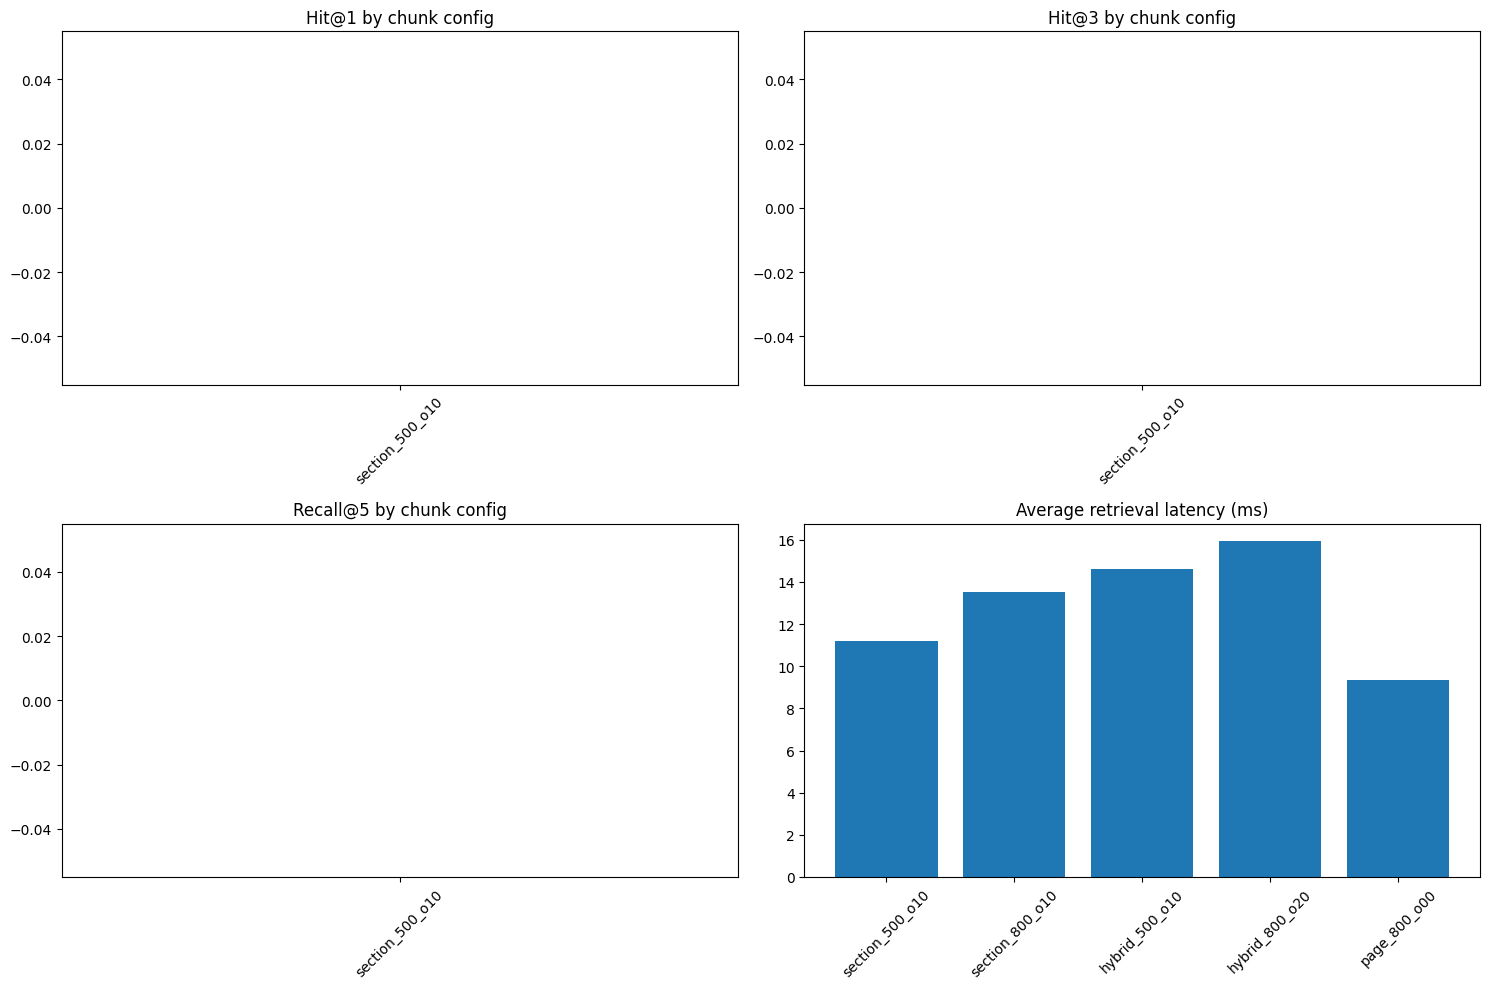

In [29]:
if retrieval_summary_df.empty:
    print('Retrieval summary is empty. Fill the gold questions and rerun the evaluation cell above.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    labels = retrieval_summary_df['config_label']

    axes[0, 0].bar(labels, retrieval_summary_df['hit_at_1'])
    axes[0, 0].set_title('Hit@1 by chunk config')
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].bar(labels, retrieval_summary_df['hit_at_3'])
    axes[0, 1].set_title('Hit@3 by chunk config')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].bar(labels, retrieval_summary_df['recall_at_5'])
    axes[1, 0].set_title('Recall@5 by chunk config')
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].bar(labels, retrieval_summary_df['latency_ms'])
    axes[1, 1].set_title('Average retrieval latency (ms)')
    axes[1, 1].tick_params(axis='x', rotation=45)

    fig.tight_layout()
    plt.show()


In [30]:
if retrieval_results_df.empty:
    print('No retrieval results yet.')
else:
    focus_question_id = retrieval_results_df['question_id'].iloc[0]
    retrieval_focus_df = retrieval_results_df[retrieval_results_df['question_id'] == focus_question_id].copy()
    print(f'Focused question: {focus_question_id}')
    display(retrieval_focus_df[[
        'config_label',
        'question',
        'supporting_pages',
        'retrieved_pages',
        'hit_at_1',
        'hit_at_3',
        'recall_at_5',
        'latency_ms',
        'top_chunk_preview',
    ]].sort_values('config_label'))


Focused question: q001


,config_label,question,supporting_pages,retrieved_pages,hit_at_1,hit_at_3,recall_at_5,latency_ms,top_chunk_preview
40,hybrid_500_o10,Does the policy automatically provide cover fo...,,"7 | 30 | 19,20 | 29,30 | 31",None,None,None,14.20,document summary of the available covers not e...
60,hybrid_800_o20,Does the policy automatically provide cover fo...,,"7 | 29,30 | 30 | 31 | 67,68",None,None,None,22.57,Document > Summary of the available covers Not...
80,page_800_o00,Does the policy automatically provide cover fo...,,7 | 30 | 31 | 24 | 19,None,None,None,9.46,document summary of the available covers not e...
0,section_500_o10,Does the policy automatically provide cover fo...,,7 | 30 | 18 | 18 | 19,None,None,None,11.76,document summary of the available covers not e...
20,section_800_o10,Does the policy automatically provide cover fo...,,7 | 30 | 18 | 18 | 19,None,None,None,11.59,document summary of the available covers not e...


## Phase 3: Semantic Retrieval

The lexical benchmark has done its job. From here, keep the parser fixed and compare retrieval backends on a small set of candidate chunk configurations instead of widening the chunk sweep.


In [ ]:
lexical_winner_label = retrieval_summary_df.iloc[0]['config_label'] if not retrieval_summary_df.empty else 'section_500_o10'
semantic_candidate_labels = []
for label in [lexical_winner_label, 'hybrid_500_o10', 'hybrid_800_o20']:
    if label in all_chunks_by_config and label not in semantic_candidate_labels:
        semantic_candidate_labels.append(label)

semantic_eval_dir = phase2_dir / 'semantic_retrieval'
semantic_eval_dir.mkdir(parents=True, exist_ok=True)

print(f'Lexical winner: {lexical_winner_label}')
pd.DataFrame({'candidate_chunk_label': semantic_candidate_labels})


## Dense Retrieval Helpers

This phase compares:
- the notebook's BM25-style lexical baseline
- a local TF-IDF cosine baseline
- a sentence-transformer dense retriever

If the sentence-transformer model is not cached locally, the first run may download it.


In [ ]:
try:
    import numpy as np
except ImportError:
    np = None

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    SentenceTransformer = None

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
except ImportError:
    TfidfVectorizer = None
    cosine_similarity = None

semantic_model_name = 'BAAI/bge-small-en-v1.5'
semantic_query_prefix = 'Represent this question for retrieving supporting passages: '


def semantic_query_text(query: str, model_name: str) -> str:
    if model_name.lower().startswith('baai/bge'):
        return semantic_query_prefix + query
    return query


def build_semantic_index(chunks: list[dict], backend: str, model_name: str = semantic_model_name) -> dict:
    texts = [chunk['text'] for chunk in chunks]
    if backend == 'tfidf':
        if TfidfVectorizer is None or cosine_similarity is None:
            raise RuntimeError('scikit-learn is not installed')
        vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1)
        matrix = vectorizer.fit_transform(texts)
        return {
            'backend': backend,
            'chunks': chunks,
            'vectorizer': vectorizer,
            'matrix': matrix,
            'model_name': 'tfidf',
        }
    if backend == 'sentence_transformers':
        if SentenceTransformer is None or np is None:
            raise RuntimeError('sentence-transformers or numpy is not installed')
        model = SentenceTransformer(model_name)
        embeddings = model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
        return {
            'backend': backend,
            'chunks': chunks,
            'model': model,
            'embeddings': np.asarray(embeddings),
            'model_name': model_name,
        }
    raise ValueError(f'Unsupported semantic backend: {backend}')


def retrieve_semantic_chunks(index_bundle: dict, query: str, top_k: int = 5) -> list[dict]:
    backend = index_bundle['backend']
    if backend == 'tfidf':
        query_vector = index_bundle['vectorizer'].transform([query])
        scores = cosine_similarity(query_vector, index_bundle['matrix'])[0]
    elif backend == 'sentence_transformers':
        query_embedding = index_bundle['model'].encode(
            [semantic_query_text(query, index_bundle['model_name'])],
            normalize_embeddings=True,
            show_progress_bar=False,
        )[0]
        scores = index_bundle['embeddings'] @ query_embedding
    else:
        raise ValueError(f'Unsupported semantic backend: {backend}')

    ranked_indices = sorted(range(len(scores)), key=lambda idx: float(scores[idx]), reverse=True)[:top_k]
    return [
        {
            'chunk': index_bundle['chunks'][idx],
            'score': round(float(scores[idx]), 4),
        }
        for idx in ranked_indices
    ]


def evaluate_retrieval_run(run_label: str, questions_df: pd.DataFrame, retrieve_fn, top_k: int = 5) -> pd.DataFrame:
    rows = []
    for question_row in questions_df.to_dict(orient='records'):
        question = str(question_row.get('question', '') or '').strip()
        if not question:
            continue
        answerable = as_bool(question_row.get('answerable', True))
        expected_pages = parse_supporting_pages(question_row.get('supporting_pages', ''))
        started = time.perf_counter()
        retrieved = retrieve_fn(question, top_k=top_k)
        latency_ms = (time.perf_counter() - started) * 1000

        retrieved_chunk_ids = [item['chunk']['chunk_id'] for item in retrieved]
        retrieved_page_sets = [item['chunk']['page_numbers'] for item in retrieved]
        relevances, relevant_ranks, retrieved_expected_pages = page_grounded_relevances(retrieved, expected_pages)

        if answerable and expected_pages:
            hit_at_1 = int(any(rank == 1 for rank in relevant_ranks))
            hit_at_3 = int(any(rank <= 3 for rank in relevant_ranks))
            recall_at_5 = round(len(retrieved_expected_pages) / len(expected_pages), 3)
            mrr_at_5 = round(1 / min(relevant_ranks), 3) if relevant_ranks and min(relevant_ranks) <= 5 else 0.0
            ideal_hits = max(1, min(top_k, len(expected_pages)))
            ideal_relevances = [1] * ideal_hits + [0] * max(0, top_k - ideal_hits)
            ndcg_at_5 = round(dcg_at_k(relevances) / max(dcg_at_k(ideal_relevances), 1e-9), 3)
            context_precision = round(sum(relevances) / top_k, 3)
            context_recall = recall_at_5
        else:
            hit_at_1 = None
            hit_at_3 = None
            recall_at_5 = None
            mrr_at_5 = None
            ndcg_at_5 = None
            context_precision = None
            context_recall = None

        rows.append({
            'run_label': run_label,
            'question_id': question_row.get('question_id', ''),
            'question': question,
            'expected_answer': question_row.get('expected_answer', ''),
            'answerable': answerable,
            'supporting_pages': ', '.join(str(page) for page in sorted(expected_pages)),
            'supporting_section_heading': question_row.get('supporting_section_heading', ''),
            'retrieved_chunk_ids': ' | '.join(retrieved_chunk_ids),
            'retrieved_pages': ' | '.join(','.join(str(page) for page in pages) for pages in retrieved_page_sets),
            'hit_at_1': hit_at_1,
            'hit_at_3': hit_at_3,
            'recall_at_5': recall_at_5,
            'mrr_at_5': mrr_at_5,
            'ndcg_at_5': ndcg_at_5,
            'context_precision': context_precision,
            'context_recall': context_recall,
            'latency_ms': round(latency_ms, 2),
            'top_chunk_score': retrieved[0]['score'] if retrieved else None,
            'top_chunk_preview': normalize_space(retrieved[0]['chunk']['text'])[:220] if retrieved else '',
        })
    return pd.DataFrame(rows)


def summarize_run_results(run_results_df: pd.DataFrame, *, retriever: str, chunk_label: str, model_name: str, error: str = '') -> dict:
    answerable_results = run_results_df[run_results_df['answerable'] == True].copy() if not run_results_df.empty else pd.DataFrame()
    return {
        'run_label': f'{retriever}::{chunk_label}',
        'retriever': retriever,
        'chunk_label': chunk_label,
        'model_name': model_name,
        'questions_evaluated': len(run_results_df),
        'answerable_questions': len(answerable_results),
        'hit_at_1': round(answerable_results['hit_at_1'].dropna().mean(), 3) if not answerable_results.empty else None,
        'hit_at_3': round(answerable_results['hit_at_3'].dropna().mean(), 3) if not answerable_results.empty else None,
        'recall_at_5': round(answerable_results['recall_at_5'].dropna().mean(), 3) if not answerable_results.empty else None,
        'mrr_at_5': round(answerable_results['mrr_at_5'].dropna().mean(), 3) if not answerable_results.empty else None,
        'ndcg_at_5': round(answerable_results['ndcg_at_5'].dropna().mean(), 3) if not answerable_results.empty else None,
        'context_precision': round(answerable_results['context_precision'].dropna().mean(), 3) if not answerable_results.empty else None,
        'context_recall': round(answerable_results['context_recall'].dropna().mean(), 3) if not answerable_results.empty else None,
        'latency_ms': round(run_results_df['latency_ms'].mean(), 2) if not run_results_df.empty else None,
        'error': error,
    }


In [ ]:
semantic_results_frames = []
semantic_summary_rows = []
semantic_failure_rows = []

for chunk_label in semantic_candidate_labels:
    chunks = all_chunks_by_config[chunk_label]

    lexical_results = evaluate_chunk_config(chunk_label, chunks, ready_gold_questions, top_k=5).copy()
    lexical_results['run_label'] = f'lexical_bm25::{chunk_label}'
    lexical_results['retriever'] = 'lexical_bm25'
    lexical_results['chunk_label'] = chunk_label
    lexical_results['model_name'] = 'bm25_notebook'
    semantic_results_frames.append(lexical_results)
    semantic_summary_rows.append(summarize_run_results(lexical_results, retriever='lexical_bm25', chunk_label=chunk_label, model_name='bm25_notebook'))

    for backend, model_name in [('tfidf', 'tfidf'), ('sentence_transformers', semantic_model_name)]:
        try:
            index_bundle = build_semantic_index(chunks, backend=backend, model_name=model_name)
            run_results = evaluate_retrieval_run(
                run_label=f'{backend}::{chunk_label}',
                questions_df=ready_gold_questions,
                retrieve_fn=lambda query, top_k=5, bundle=index_bundle: retrieve_semantic_chunks(bundle, query, top_k=top_k),
                top_k=5,
            )
            run_results['retriever'] = backend
            run_results['chunk_label'] = chunk_label
            run_results['model_name'] = model_name
            semantic_results_frames.append(run_results)
            semantic_summary_rows.append(summarize_run_results(run_results, retriever=backend, chunk_label=chunk_label, model_name=model_name))
        except Exception as exc:
            semantic_failure_rows.append({
                'retriever': backend,
                'chunk_label': chunk_label,
                'model_name': model_name,
                'error': f'{type(exc).__name__}: {exc}',
            })
            semantic_summary_rows.append({
                'run_label': f'{backend}::{chunk_label}',
                'retriever': backend,
                'chunk_label': chunk_label,
                'model_name': model_name,
                'questions_evaluated': 0,
                'answerable_questions': 0,
                'hit_at_1': None,
                'hit_at_3': None,
                'recall_at_5': None,
                'mrr_at_5': None,
                'ndcg_at_5': None,
                'context_precision': None,
                'context_recall': None,
                'latency_ms': None,
                'error': f'{type(exc).__name__}: {exc}',
            })

semantic_results_df = pd.concat(semantic_results_frames, ignore_index=True) if semantic_results_frames else pd.DataFrame()
semantic_summary_df = pd.DataFrame(semantic_summary_rows).sort_values(
    ['hit_at_1', 'mrr_at_5', 'recall_at_5'],
    ascending=[False, False, False],
    na_position='last',
).reset_index(drop=True)
semantic_failures_df = pd.DataFrame(semantic_failure_rows)

semantic_results_df.to_csv(semantic_eval_dir / 'semantic_retrieval_results.csv', index=False)
semantic_summary_df.to_csv(semantic_eval_dir / 'semantic_retrieval_summary.csv', index=False)
semantic_failures_df.to_csv(semantic_eval_dir / 'semantic_retrieval_failures.csv', index=False)

display(semantic_summary_df)
if not semantic_failures_df.empty:
    print('Semantic retrieval failures')
    display(semantic_failures_df)


## Semantic Retrieval Visual Review

Compare the lexical and dense runs on the same questions before deciding whether to keep the smaller section-aware chunks or switch to a hybrid chunk shape for dense retrieval.


In [ ]:
if semantic_summary_df.empty:
    print('Semantic retrieval summary is empty.')
else:
    plot_df = semantic_summary_df[semantic_summary_df['error'].fillna('') == ''].copy()
    labels = plot_df['run_label']
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    axes[0, 0].bar(labels, plot_df['hit_at_1'])
    axes[0, 0].set_title('Hit@1 by retrieval run')
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].bar(labels, plot_df['hit_at_3'])
    axes[0, 1].set_title('Hit@3 by retrieval run')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].bar(labels, plot_df['recall_at_5'])
    axes[1, 0].set_title('Recall@5 by retrieval run')
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].bar(labels, plot_df['latency_ms'])
    axes[1, 1].set_title('Average retrieval latency (ms)')
    axes[1, 1].tick_params(axis='x', rotation=45)

    fig.tight_layout()
    plt.show()


In [ ]:
if semantic_results_df.empty:
    print('No semantic retrieval results yet.')
else:
    semantic_focus_question_id = semantic_results_df['question_id'].iloc[0]
    semantic_focus_df = semantic_results_df[semantic_results_df['question_id'] == semantic_focus_question_id].copy()
    print(f'Focused question: {semantic_focus_question_id}')
    display(semantic_focus_df[[
        'run_label',
        'retriever',
        'chunk_label',
        'supporting_pages',
        'retrieved_pages',
        'hit_at_1',
        'hit_at_3',
        'recall_at_5',
        'latency_ms',
        'top_chunk_score',
        'top_chunk_preview',
    ]].sort_values('run_label'))


## Next Decision After This Notebook

At this point the order should be:
1. keep `docling` fixed as the parser for this one-PDF experiment
2. keep `section_500_o10` as the lexical default unless the dense comparison clearly shows a better chunk shape
3. choose one retrieval stack from the Phase 3 comparison and freeze it
4. only then add answer synthesis, citations, and guardrails in a small package or app structure
